In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
    
from data.nuscenes_wrapper import TextLiDARPairDataset, collate_text_lidar_pairs, filter_small_pointclouds
from utils.sparse2dense import sparse_to_dense
from utils.visualize import visualize_point_cloud

import torch
from tqdm.notebook import tqdm

In [2]:
SparseCLIP_dataset = torch.load('../data/nuscenes_tp_train.pt')
filtered_dataset = filter_small_pointclouds(SparseCLIP_dataset, min_points=5)

Filtering small pointclouds: 100%|██████████| 931582/931582 [00:01<00:00, 559268.87it/s]

Original samples: 931582
Filtered out (less than 5 points): 491612
Remaining samples: 439970


In [3]:
SparseCLIP_train_dataloader = torch.utils.data.DataLoader(
    filtered_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=lambda batch: collate_text_lidar_pairs(batch, sparse_to_dense_fn=sparse_to_dense)
)

In [4]:
for batch in SparseCLIP_train_dataloader:
    sample = batch
    print(sample)
    break

(['a pointcloud of trailer', 'a pointcloud of pedestrian', 'a pointcloud of trafficcone', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of trafficcone', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of barrier', 'a pointcloud of pedestrian', 'a pointcloud of trailer', 'a pointcloud of car', 'a pointcloud of pedestrian', 'a pointcloud of barrier', 'a pointcloud of car', 'a pointcloud of pedestrian', 'a pointcloud of trafficcone', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of truck', 'a pointcloud of motorcycle', 'a pointcloud of pedestrian', 'a pointcloud of truck', 'a pointcloud of truck', 'a pointcloud of bus', 'a pointcloud of pedestrian', 'a pointcloud of trafficcone', 'a pointcloud of pushable_pullable', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of pedestrian', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of car', 'a pointcloud of bus', 'a pointcloud of motorc

a pointcloud of trailer
torch.Size([1024, 3])


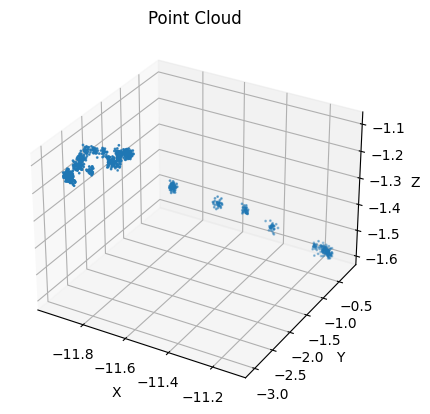

In [5]:
# [2, Batch size]
batch = 0
print(sample[0][batch]) # string label

points = sample[1][batch]
print(points.shape) # point cloud tensor
visualize_point_cloud(points)

In [6]:
len(sample[0])

128

torch.Size([1024, 3])


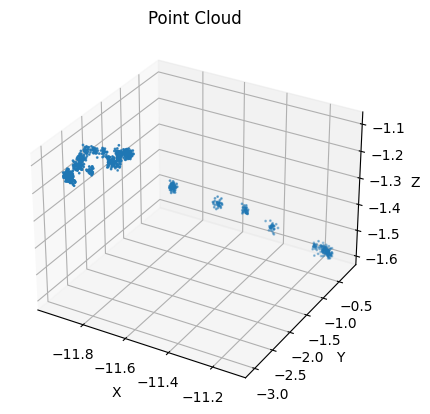

In [7]:
pt2 = sparse_to_dense(sample[1][batch])
print(pt2.shape)  # [target_num_points, 3]
visualize_point_cloud(pt2)

In [8]:
type(sample[0])

list

In [9]:
sample[1].shape

torch.Size([128, 1024, 3])